In [1]:
# Parameters
summary_config = {"run_run_comparison": False, "run_RTP_summary": False, "run_validation": False, "run_network_validation": True, "summary_list": {"RTP-summary-notebook": ["RTP_index", "RTP_congestion", "RTP_topsheet", "RTP_MIC", "RTP_person", "RTP_household", "RTP_access", "RTP_costs", "RTP_walk_bike", "RTP_emissions", "RTP_mode_share", "RTP_freight", "RTP_transit"], "activitysim-validation-notebook": ["work_from_home", "auto_ownership", "telecommute_frequency", "free_parking", "cdap", "intermediate_stop_frequency", "trip_purpose", "trip_destination_choice", "school_location", "work_location", "mandatory_tour_frequency", "mandatory_tour_scheduling", "non_mandatory_tour_frequency", "non_mandatory_tour_destination_choice", "non_mandatory_tour_scheduling", "joint_tour_frequency", "joint_tour_composition", "atwork_subtours_frequency", "atwork_subtours_destination_choice", "atwork_subtours_scheduling", "atwork_subtour_mode", "tour_mode_choice", "trip_mode_choice"], "daysim-validation-notebook": ["all_tour_mode", "all_trip_mode", "auto_ownership", "day_pattern", "escort_tour_mode", "escort_trip_mode", "households", "intermediate_stop_generation", "other_home_based_tour_mode", "other_home_based_trip_mode", "persons", "school_location", "school_tour_mode", "school_trip_mode", "telecommute", "time_choice", "tours", "tour_destination", "transit_pass_ownership", "trips", "trip_destination", "workbased_subtour_generation", "workbased_subtour_mode", "work_location", "work_tour_mode", "work_trip_mode"], "network-validation-notebook": ["JBLM", "supplementals", "transit_validation", "traffic_validation", "bike_validation", "link_analysis"], "run-comparison-notebook": ["topsheet", "population", "parking", "vmt", "transit"]}, "p_output_dir": "outputs/summary", "output_folder": "outputs", "survey_folder": "inputs/base_year/survey", "uncloned_folder": "uncloned", "sc_run_name": "current run", "sc_run_path": "../../../../", "survey_directories": {"survey": "../../../../inputs/base_year/survey"}, "comparison_runs_list": {"2050 new transit, old network": "\\\\modelstation3\\c$\\Workspace\\sc_new_2050_transit\\soundcast", "2050 urbansim": "\\\\modelstation2\\c$\\Workspace\\sc_2050_urbansim2_07_30_25"}, "county_map": {"33": "King", "35": "Kitsap", "53": "Pierce", "61": "Snohomish"}, "uc_list": ["@sov_inc1", "@sov_inc2", "@sov_inc3", "@hov2_inc1", "@hov2_inc2", "@hov2_inc3", "@hov3_inc1", "@hov3_inc2", "@hov3_inc3", "@av_sov_inc1", "@av_sov_inc2", "@av_sov_inc3", "@av_hov2_inc1", "@av_hov2_inc2", "@av_hov2_inc3", "@av_hov3_inc1", "@av_hov3_inc2", "@av_hov3_inc3", "@tnc_inc1", "@tnc_inc2", "@tnc_inc3", "@mveh", "@hveh", "@bveh"], "agency_lookup": {"1": "King County Metro", "2": "Pierce Transit", "3": "Community Transit", "4": "Kitsap Transit", "5": "Washington Ferries", "6": "Sound Transit", "7": "Everett Transit"}, "emissions_scenario": "standard", "tot_veh_model_base_year": 3185281, "speed_bins": [-999999.0, 2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5, 72.5, 999999.0], "fac_type_lookup": {"0": 0, "1": 4, "2": 4, "3": 5, "4": 5, "5": 5, "6": 3, "7": 5, "8": 0}, "tod_lookup": {"5to9": 5, "9to15": 9, "15to18": 15, "18to20": 18, "20to5": 20}, "summer_list": [87], "special_route_lookup": {"1671": "A-Line Rapid Ride", "1672": "B-Line Rapid Ride", "1673": "C-Line Rapid Ride", "1674": "D-Line Rapid Ride", "1675": "E-Line Rapid Ride", "1677": "H-Line Rapid Ride", "4950": "Central Link", "6995": "Tacoma Link", "6998": "Sounder South", "6999": "Sounder North", "3701": "Swift Blue Line", "3702": "Swift Green Line"}}
input_config = {"debug_skims_and_paths": False, "model_year": "2023", "base_year": "2023", "landuse_inputs": "23_on_23_v3", "network_inputs": "base_year_2023_final", "db_name": "soundcast_inputs_2023.db", "soundcast_inputs_dir": "R:/e2projects_two/SoundCast/Inputs/rtp_2026_2050", "abm_model": "daysim", "run_accessibility_calcs": False, "run_setup_emme_project_folders": False, "run_setup_emme_bank_folders": False, "run_copy_scenario_inputs": False, "run_import_networks": False, "run_skims_and_paths_free_flow": False, "run_skims_and_paths": False, "run_truck_model": False, "run_supplemental_trips": False, "run_daysim": False, "run_summaries": True, "include_av": False, "include_tnc": True, "tnc_av": False, "include_tnc_to_transit": False, "include_knr_to_transit": False, "include_delivery": False, "include_telecommute": True, "run_integrated": False, "should_build_shadow_price": False, "delete_banks": False, "include_tnc_emissions": True, "add_distance_pricing": False, "distance_rate_dict": {"am": 13.5, "md": 8.5, "pm": 13.5, "ev": 8.5, "ni": 8.5}}


In [2]:
import os
import pandas as pd
import numpy as np
from sqlalchemy import create_engine,text
from scipy import stats
import plotly.express as px
import toml
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
import sys

sys.path.append("../../notebook_styling")
import psrc_theme

input_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'input_configuration.toml'))
valid_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'validation_configuration.toml'))
summary_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'summary_configuration.toml'))

# create connection
conn = create_engine('sqlite:///../../../../inputs/db/'+input_config['db_name'])
# summary data location
csv_path = os.path.join(valid_config['model_dir'], 'outputs/validation')

# table format
pd.options.display.float_format = '{:0,.0f}'.format
format_percent = "{:,.2%}".format

## transit boarding

### boarding by mode

In [3]:
# Process 2024 observed data
df_obs = pd.read_sql(text("SELECT * FROM observed_transit_boardings"), con=conn.connect())

df_obs["route_id"] = df_obs["route_id"].astype("int")

df_obs = df_obs[df_obs['year'].isin([2023,2024])]

df_obs = pd.pivot_table(df_obs, index='route_id', values='observed_daily', columns='year', aggfunc='sum')
df_obs = df_obs.reset_index()



In [4]:

# Load model results and calculate modeled daily boarding by line
df_transit_line = pd.read_csv(os.path.join(valid_config['model_dir'], 'outputs/transit/transit_line_results.csv'))
df_model = df_transit_line.copy()
df_model_daily = (
    df_model.groupby(["route_code", "mode",'agency_code'])
    .agg({"description": "first", "boardings": "sum"})
    .reset_index()
)

# Merge modeled with observed boarding data
df_model_daily["route_code"] = df_model_daily["route_code"].astype("int")
df = df_model_daily.merge(
    df_obs, left_on="route_code", right_on="route_id", how="left"
)

df.rename(
    columns={
        "boardings": "Model",
        2023: "2023 Spring Observed",
        2024: "2024 Spring Observed",
    },
    inplace=True,
)


df['agency'] = df['agency_code'].astype('int').astype('str').map(summary_config['agency_lookup'])
df_line_boardings_23_24 = df.copy()

In [5]:
df = pd.read_csv(os.path.join(csv_path, 'daily_boardings_by_mode.csv')).sort_values('model_boardings', ascending=False)
table_df = df.copy()
table_df['mode_name'] = table_df['mode'].map({'c':'Commuter Rail','b':'Bus','r':'Rail','f':'Ferry (1)','p':'Ferry (2)'})
# table_df[['mode','mode_name','model_boardings','2023','2024']]
table_df.rename(
    columns={
        "model_boardings": "Model",
        "2023": "2023 Spring Observed",
        "2024": "2024 Spring Observed",
    },
    inplace=True,
)
table_df[['mode','mode_name','Model','2023 Spring Observed','2024 Spring Observed']]

,mode,mode_name,Model,2023 Spring Observed,2024 Spring Observed
0,b,Bus,"392,285","332,482","356,415"
4,r,Rail,"87,559","86,474","94,918"
2,f,Ferry (1),"11,928","9,907","10,881"
1,c,Commuter Rail,"7,056","6,763","7,702"
3,p,Ferry (2),"4,935","3,379","3,722"


In [6]:
df_boarding_line = pd.read_csv(os.path.join(csv_path,'daily_boardings_by_line.csv'), index_col='description')
# df_boarding_line[['2023','model_boardings']] = df_boarding_line[['2023','model_boardings']].astype('float')

df = df_boarding_line[df_boarding_line['route_code'].isin([6996,6999,6998])].reset_index()
df.index = df['route_code']
df.loc[6996,'line'] = 'Link 1 Line'
df.loc[6999,'line'] = 'Sounder'
df.loc[6998,'line'] = 'Sounder'
df = df.groupby('line').sum()[['model_boardings','2023','2024']]
df.rename(columns={'model_boardings': 'Model'}, inplace=True)


df['2023 % diff'] = (df['Model'].astype(float)-df['2023'].astype(float))/df['2023'].astype(float)
df['2024 % diff'] = (df['Model'].astype(float)-df['2024'].astype(float))/df['2024'].astype(float)
df[['2023 % diff']] = df[['2023 % diff']].applymap(format_percent)
df[['2024 % diff']] = df[['2024 % diff']].applymap(format_percent)

for col in ['Model','2023','2024']:
    df[col] = df[col].astype(float).map('{:,.0f}'.format)
df

C:\Users\modeller\AppData\Local\Temp\ipykernel_13212\2196298059.py:15: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

C:\Users\modeller\AppData\Local\Temp\ipykernel_13212\2196298059.py:16: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,Model,2023,2024,2023 % diff,2024 % diff
line,,,,,
Link 1 Line,"84,937","78,772","85,427",7.83%,-0.57%
Sounder,"7,056","6,763","7,702",4.33%,-8.39%


### boarding by agency

In [7]:
df = pd.read_csv(os.path.join(csv_path, 'daily_boardings_by_agency.csv'))
# # plot_df = df.melt(id_vars=['agency'], value_vars=['observed_boardings', 'model_boardings'],
# #                   var_name='source', value_name='count')
# df_boarding_line = pd.read_csv(os.path.join(csv_path,'daily_boardings_by_line.csv'), index_col='description')
# df = df_boarding_line.groupby('agency').sum()[['model_boardings','2023','2024']].sort_values('2023', ascending=False)
df.rename(columns={'model_boardings': 'Model'}, inplace=True)
for col in ['Model','2023','2024']:
    df[col] = df[col].astype(float).map('{:,.0f}'.format)
df

,agency,Model,2023,2024
0,Community Transit,"26,622","21,752","28,676"
1,Everett Transit,"4,967","4,201","6,027"
2,King County Metro,"288,926","254,568","283,754"
3,Kitsap Transit,"13,826","8,258","10,059"
4,Pierce Transit,"23,589","21,185","22,042"
5,Sound Transit,"137,023","115,114","140,367"
6,Washington Ferries,"8,810","7,883","8,614"


In [8]:
# df = pd.read_csv(os.path.join(csv_path, 'daily_boardings_by_line.csv')).sort_values('observed_boardings', ascending=False)
df = df_line_boardings_23_24.copy()
df
df = df[df['mode'].isin(['b'])]
df = df.groupby(['agency'])[['Model','2023 Spring Observed','2024 Spring Observed']].sum()
df


,Model,2023 Spring Observed,2024 Spring Observed
agency,,,
Community Transit,"26,622","21,752","22,092"
Everett Transit,"4,967","4,201","5,862"
King County Metro,"287,352","252,852","270,215"
Kitsap Transit,"6,914","4,048","5,043"
Pierce Transit,"23,589","21,185","21,911"
Sound Transit,"42,841","28,444","31,292"


### boarding by key route

In [9]:

df = df_line_boardings_23_24[df_line_boardings_23_24['mode'].isin(['f','p'])][['route_code','description','agency','Model','2023 Spring Observed','2024 Spring Observed']]
df = df[df['route_code'].isin([4200,4201,4203,4204,5001,5002,5003,5004,5005,5006,5007,1973,1975])].reset_index()
df.drop(['route_code','agency'], axis=1, inplace=True)
df_table = df.copy()
# df_table[['perc_diff']] = df_table[['perc_diff']].applymap(format_percent)
df_table.sort_values('Model', ascending=False)

,index,description,Model,2023 Spring Observed,2024 Spring Observed
7,279,WSF Seattle-Bain Isl,"6,328","4,981","5,404"
2,270,Seattle-Bremerton FF,"3,634","1,913","2,068"
3,271,Brem-Pt Orchard FF,"1,915",768,857
10,282,WSF Fauntleroy-Vashn,"1,133",659,661
5,274,Seattle-Southwrth FF,702,631,749
0,147,973 W Sea Water Taxi,678,837,873
1,148,975 Vashn Water Taxi,464,356,390
9,281,WSF Fauntleroy-Swrth,460,134,184
6,278,WSF Edmonds-Kingston,419,"1,020","1,068"
4,273,Seattle-Kingston FF,267,429,484


In [10]:
# if len(df) > 0:
#     ax = df.plot(kind='scatter', x='observed_boardings', y='model_boardings')
#     lim = df[['observed_boardings','model_boardings']].max().max()*1.05
#     ax.set_ylim(0,lim)
#     ax.set_xlim(0,lim)
#     x = np.linspace(*ax.get_xlim())
#     ax.plot(x, x)
#     slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed_boardings'],df['model_boardings'])
#     print('r^2 ' + str('') + ': ' + str(r_value))

In [11]:
df = df_line_boardings_23_24[df_line_boardings_23_24['route_code'].isin([6996,6999,6998])].reset_index()
df['description'] = df['route_code'].map({6998: 'Sounder South', 6999: 'Sounder North',6996: 'Link Red Line'})
# df.drop(['route_code','agency'], axis=1, inplace=True)
df_table = df[['route_code','description','agency','Model','2023 Spring Observed','2024 Spring Observed']].copy()
# df_table[['perc_diff']] = df_table[['perc_diff']].applymap(format_percent)
df_table

,route_code,description,agency,Model,2023 Spring Observed,2024 Spring Observed
0,6996,Link Red Line,Sound Transit,"84,937","78,772","85,427"
1,6998,Sounder South,Sound Transit,"7,049","6,422","7,335"
2,6999,Sounder North,Sound Transit,7,341,367


In [12]:
# if len(df) > 0:
#     ax = df.plot(kind='scatter', x='observed_boardings', y='model_boardings')
#     lim = df[['observed_boardings','model_boardings']].max().max()*1.05
#     ax.set_ylim(0,lim)
#     ax.set_xlim(0,lim)
#     x = np.linspace(*ax.get_xlim())
#     ax.plot(x, x)
#     slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed_boardings'],df['model_boardings'])
#     print('r^2 ' + str('') + ': ' + str(r_value))

In [13]:
# df = df_boarding_key[df_boarding_key['route_code'].isin([1671,1672,1673,1674,1675,1676,6550,1007,1040,1997,1998])].reset_index()
# df['description'] = df['route_code'].map({1671: 'A Line RapidRide', 1672: 'B Line RapidRide',
#                                             1673: 'C Line RapidRide', 1674: 'D Line RapidRide',
#                                             1675: 'E Line RapidRide', 1676: 'F Line RapidRide',
#                                             6550: 'Sound Transit 550', 1040: 'KC Metro 40', 1007: 'KC Metro 7',
#                                             1997: 'SLU Streetcar', 1998: 'First Hill Streetcar'})
# df.drop(['route_code','agency'], axis=1, inplace=True)

df = df_line_boardings_23_24[df_line_boardings_23_24['route_code'].isin([1671,1672,1673,1674,1675,1676,6550,1007,1040,1997,1998])].reset_index()
df['description'] = df['route_code'].map({1671: 'A Line RapidRide', 1672: 'B Line RapidRide',
                                            1673: 'C Line RapidRide', 1674: 'D Line RapidRide',
                                            1675: 'E Line RapidRide', 1676: 'F Line RapidRide',
                                            6550: 'Sound Transit 550', 1040: 'KC Metro 40', 1007: 'KC Metro 7',
                                            1997: 'SLU Streetcar', 1998: 'First Hill Streetcar'})
# df.drop(['route_code','agency'], axis=1, inplace=True)
df_table = df[['route_code','description','agency','Model','2023 Spring Observed','2024 Spring Observed']].copy()

df_table = df[['route_code','description','agency','Model','2023 Spring Observed','2024 Spring Observed']].copy()
df_table.sort_values('Model', ascending=False)

,route_code,description,agency,Model,2023 Spring Observed,2024 Spring Observed
6,1675,E Line RapidRide,King County Metro,"15,260","11,057","13,011"
4,1673,C Line RapidRide,King County Metro,"10,883","7,224","7,541"
0,1007,KC Metro 7,King County Metro,"10,399","10,059","10,819"
1,1040,KC Metro 40,King County Metro,"8,436","7,218","8,255"
2,1671,A Line RapidRide,King County Metro,"8,022","8,178","9,415"
5,1674,D Line RapidRide,King County Metro,"6,977","8,805","9,634"
10,6550,Sound Transit 550,Sound Transit,"6,686","3,677","4,074"
7,1676,F Line RapidRide,King County Metro,"6,113","4,548","4,968"
3,1672,B Line RapidRide,King County Metro,"3,609","4,214","4,694"
9,1998,First Hill Streetcar,King County Metro,865,"3,915","4,115"


In [14]:
# if len(df) > 0:
#     ax = df.plot(kind='scatter', x='observed_boardings', y='model_boardings')
#     lim = df[['observed_boardings', 'model_boardings']].max().max() * 1.05
#     ax.set_ylim(0, lim)
#     ax.set_xlim(0, lim)
#     x = np.linspace(*ax.get_xlim())
#     ax.plot(x, x)
#     slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed_boardings'], df['model_boardings'])
#     print('r^2 ' + str('') + ': ' + str(r_value))

### Top routes by agency

In [15]:
# df = pd.read_csv(os.path.join(csv_path, 'daily_boardings_by_line.csv'))
df = df_line_boardings_23_24.copy()
# df_top = pd.DataFrame()
# for agency in df['agency'].unique():
#     _df = df[df['agency'] == agency].sort_values('model_boardings', ascending=False).head(8)
#     df_top = pd.concat([df_top, _df])
# df = df_top[['agency','description','mode','model_boardings','observed_boardings','diff','perc_diff']]
cols=['agency','description','mode','Model','2023 Spring Observed','2024 Spring Observed']

In [16]:
agency = 'King County Metro'
df[df['agency'] == agency].sort_values('Model', ascending=False).head(10)[cols]

,agency,description,mode,Model,2023 Spring Observed,2024 Spring Observed
130,King County Metro,E-Line,b,"15,260","11,057","13,011"
128,King County Metro,C Line,b,"10,883","7,224","7,541"
5,King County Metro,7 Rain Bch-ColC-CBD,b,"10,399","10,059","10,819"
28,King County Metro,40 Ngt-Bal-Fre-CBD,b,"8,436","7,218","8,255"
126,King County Metro,A Line,b,"8,022","8,178","9,415"
43,King County Metro,70 Udst-Elake-CBD,b,"7,968","4,298","4,658"
103,King County Metro,255 TLk-Juan-Krk-UD,b,"7,177","2,554","3,017"
129,King County Metro,D Line,b,"6,977","8,805","9,634"
64,King County Metro,150 Kent-SC-Tuk-CBD,b,"6,959","4,067","4,311"
67,King County Metro,160 Aub-Kent-Rent,b,"6,808","5,008","5,492"


In [17]:
agency = 'Sound Transit'
df[df['agency'] == agency].sort_values('Model', ascending=False).head(10)[cols]

,agency,description,mode,Model,2023 Spring Observed,2024 Spring Observed
309,Sound Transit,Light Rail Ang Lk-NG,r,"84,937","78,772","85,427"
310,Sound Transit,Commutr Rail Tac-Sea,c,"7,049","6,422","7,335"
293,Sound Transit,550 Bellevue-Seattle,b,"6,686","3,677","4,074"
292,Sound Transit,545 Redmond-Seattle,b,"5,856","4,075","4,816"
288,Sound Transit,522 Woodinvl-Roosvlt,b,"5,178","1,756","2,286"
294,Sound Transit,554 Issaquah-Seattle,b,"4,180","2,415","2,783"
286,Sound Transit,512 Everett-Northgte,b,"4,090","2,306","2,937"
300,Sound Transit,578 Seattle-Puyallup,b,"3,033","1,523","1,614"
298,Sound Transit,574 Lakewood-SeaTac,b,"2,225","1,870","1,764"
308,Sound Transit,Light Rail Tacoma,r,"2,189","1,544","3,496"


In [18]:
agency = 'Community Transit'
df[df['agency'] == agency].sort_values('Model', ascending=False).head(10)[cols]

,agency,description,mode,Model,2023 Spring Observed,2024 Spring Observed
230,Community Transit,Swift Blue,b,"6,086","5,403","6,278"
231,Community Transit,Swift Green,b,"2,461","2,017","2,748"
200,Community Transit,116 Edm-Silver Firs,b,"2,083","1,072",0
199,Community Transit,115 McClm P&R-AurVil,b,"1,560",965,0
206,Community Transit,202 Smokey Pt-Lynnwd,b,"1,503","1,139","1,320"
205,Community Transit,201 Smokey Pt-Lynnwd,b,"1,474","1,081","1,298"
191,Community Transit,101 Mar P&R-Aur Vill,b,"1,286",810,868
203,Community Transit,130 Edmonds-Lynnwood,b,859,473,516
198,Community Transit,113 Mukilteo-Lynn TC,b,811,764,812
195,Community Transit,109 Ash Wy P&R-LkStv,b,660,339,370


In [19]:
agency = 'Pierce Transit'
df[df['agency'] == agency].sort_values('Model', ascending=False).head(10)[cols]

,agency,description,mode,Model,2023 Spring Observed,2024 Spring Observed
160,Pierce Transit,1 6th Ave-Pac Ave,b,"2,965","3,035","3,633"
161,Pierce Transit,2 S 19th-Bridgeport,b,"1,989","1,729","1,774"
162,Pierce Transit,3 Lakewood-Tacoma,b,"1,679","1,250","1,525"
184,Pierce Transit,400 Puyllp-Tacoma,b,"1,422",336,362
185,Pierce Transit,402 Meridian,b,"1,379",626,761
163,Pierce Transit,4 Lakewd-South Hill,b,"1,170",968,"1,023"
189,Pierce Transit,500 Federal Way,b,"1,103",845,827
169,Pierce Transit,41 S 56th St-Salish,b,"1,040","1,088","1,061"
172,Pierce Transit,48 Sheridan-M St,b,"1,010","1,065","1,134"
190,Pierce Transit,501 Miltn-Fed Way,b,992,431,488


In [20]:
agency = 'Kitsap Transit'
df[df['agency'] == agency].sort_values('Model', ascending=False).head(10)[cols]

,agency,description,mode,Model,2023 Spring Observed,2024 Spring Observed
270,Kitsap Transit,Seattle-Bremerton FF,f,"3,634","1,913","2,068"
271,Kitsap Transit,Brem-Pt Orchard FF,p,"1,915",768,857
244,Kitsap Transit,217 Brem-Silverdle E,b,957,417,876
260,Kitsap Transit,390 Poulsbo-Bainbrdg,b,878,170,238
242,Kitsap Transit,212 Brem-Silverdle W,b,770,679,758
274,Kitsap Transit,Seattle-Southwrth FF,f,702,631,749
259,Kitsap Transit,86 Southwrth Shuttle,b,592,91,134
254,Kitsap Transit,333 Silvrdale-Bainb,b,518,114,132
272,Kitsap Transit,Brem-Annapolis FF,p,394,469,568
240,Kitsap Transit,8 Bethel,b,337,152,173


In [21]:
agency = 'Everett Transit'
df[df['agency'] == agency].sort_values('Model', ascending=False).head(10)[cols]

,agency,description,mode,Model,2023 Spring Observed,2024 Spring Observed
316,Everett Transit,7 Coll Stn-Mall Stn,b,"2,671","2,239","2,958"
320,Everett Transit,29 Coll Stn-Mall Stn,b,"1,290",881,"1,185"
313,Everett Transit,3 Seaway TC-Evt Stn,b,391,285,381
317,Everett Transit,8 Airport Rd-Evt Stn,b,141,156,201
315,Everett Transit,6 Waterfront-Evt Stn,b,127,62,91
312,Everett Transit,2 Marnr P&R-Mall Stn,b,100,148,255
318,Everett Transit,12 Mall Stn-Seawy TC,b,88,256,457
314,Everett Transit,4 Evt Stn-Collge Stn,b,84,114,198
319,Everett Transit,18 Mukilteo-Evt Stn,b,76,60,136


### boarding by time of day

In [22]:
def create_tod_chart(df):
    # Create a figure
    fig = go.Figure()

    descriptions = df['description'].unique()

    # Add traces for each description
    for description in descriptions:
        _df = df[df['description'] == description].copy()
        _df = pd.pivot_table(_df, index='tod', columns='description', values='boardings')

        tod_list = []
        for tod in ['5to6', '6to7', '7to8', '8to9', '9to10', '14to15', '15to16', '16to17', '17to18']:
            if tod in _df.index:
                tod_list.append(tod)

        # Smooth out time periods
        if '10to14' in _df.index:
            _df.loc['10to11'] = _df.loc['10to14'] / 4.0
            _df.loc['11to12'] = _df.loc['10to14'] / 4.0
            _df.loc['12to13'] = _df.loc['10to14'] / 4.0
            _df.loc['13to14'] = _df.loc['10to14'] / 4.0
            tod_list += ['10to11', '11to12', '12to13', '13to14']
            _df.drop('10to14', inplace=True)

        if '18to20' in _df.index:
            _df.loc['18to19'] = _df.loc['18to20'] / 2.0
            _df.loc['19to20'] = _df.loc['18to20'] / 2.0
            tod_list += ['18to19', '19to20']
            _df.drop('18to20', inplace=True)
        if '20to5' in _df.index:
            tod_list += ['20to21', '21to22', '22to23', '23to0', '0to1', '1to2', '2to3', '3to4', '4to5']
            _df.loc['20to21'] = _df.loc['20to5'] / 9.0
            _df.loc['21to22'] = _df.loc['20to5'] / 9.0
            _df.loc['22to23'] = _df.loc['20to5'] / 9.0
            _df.loc['23to0'] = _df.loc['20to5'] / 9.0
            _df.loc['0to1'] = _df.loc['20to5'] / 9.0
            _df.loc['1to2'] = _df.loc['20to5'] / 9.0
            _df.loc['2to3'] = _df.loc['20to5'] / 9.0
            _df.loc['3to4'] = _df.loc['20to5'] / 9.0
            _df.loc['4to5'] = _df.loc['20to5'] / 9.0
            _df.drop('20to5', inplace=True)

        _df = _df.reset_index()
        _df.index = _df.tod
        _df.drop('tod', axis=1, inplace=True)
        _df = _df.loc[_df.index, description]
        _df = _df.loc[tod_list]

        fig.add_trace(go.Scatter(x=_df.index, y=_df, mode='lines', name=description, visible=False))

    # Make the first trace visible
    fig.data[0].visible = True

    # Create dropdown menu
    dropdown_buttons = [
        {'label': description, 'method': 'update', 'args': [{'visible': [description == desc for desc in descriptions]}, {'title': f'Route: {description} (Daily Boardings: {df[df["description"] == description]["boardings"].sum():,.0f})'}]}
        for description in descriptions
    ]

    # Update layout with dropdown
    fig.update_layout(
        updatemenus=[{
            'buttons': dropdown_buttons,
            'direction': 'down',
            'showactive': True,
        }],
        title=f'Route: {descriptions[0]} (Daily Boardings: {df[df["description"] == descriptions[0]]["boardings"].sum():,.0f})',
        height=500,
        width=900,
        font=dict(size=11),
        yaxis_tickformat='.00f'
    )

    return fig

In [23]:
df_transit_line['agency'] = df_transit_line['agency_code'].astype('int').astype('str').map(summary_config['agency_lookup'])

agency = 'King County Metro'
df = df_transit_line[df_transit_line['agency'] == agency]
df = df.groupby(['tod', 'description']).agg({'boardings': 'sum'}).reset_index()
fig = create_tod_chart(df)
fig.show()

In [24]:
agency = 'Sound Transit'
df = df_transit_line[df_transit_line['agency'] == agency]
df = df.groupby(['tod', 'description']).agg({'boardings': 'sum'}).reset_index()
fig = create_tod_chart(df)
fig.show()

In [25]:
agency = 'Community Transit'
df = df_transit_line[df_transit_line['agency'] == agency]
df = df.groupby(['tod', 'description']).agg({'boardings': 'sum'}).reset_index()
fig = create_tod_chart(df)
fig.show()

In [26]:
agency = 'Pierce Transit'
df = df_transit_line[df_transit_line['agency'] == agency]
df = df.groupby(['tod', 'description']).agg({'boardings': 'sum'}).reset_index()
fig = create_tod_chart(df)
fig.show()

In [27]:
agency = 'Kitsap Transit'
df = df_transit_line[df_transit_line['agency'] == agency]
df = df.groupby(['tod', 'description']).agg({'boardings': 'sum'}).reset_index()
fig = create_tod_chart(df)
fig.show()

In [28]:
agency = 'Everett Transit'
df = df_transit_line[df_transit_line['agency'] == agency]
df = df.groupby(['tod', 'description']).agg({'boardings': 'sum'}).reset_index()
fig = create_tod_chart(df)
fig.show()

### boarding on lines by agency

In [29]:
df = pd.read_csv(os.path.join(csv_path,'daily_boardings_by_line.csv'), index_col='agency')

r^2 Community Transit: 0.9798147325926135
r^2 Everett Transit: 0.9909504366293809
r^2 King County Metro: 0.9143908161445555
r^2 Kitsap Transit: 0.9267654654766418
r^2 Pierce Transit: 0.8602180341444968
r^2 Sound Transit: 0.9982867843404932


r^2 Washington Ferries: 0.9780475268858217


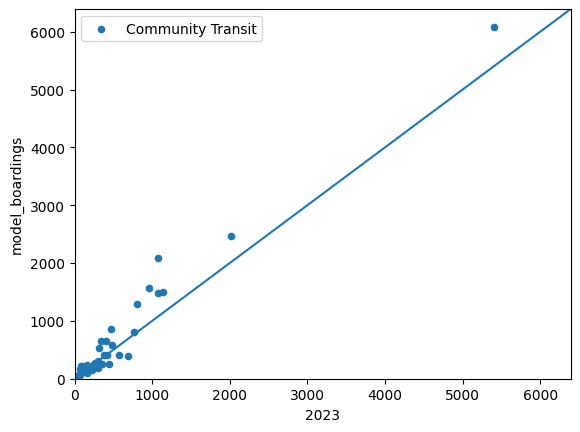

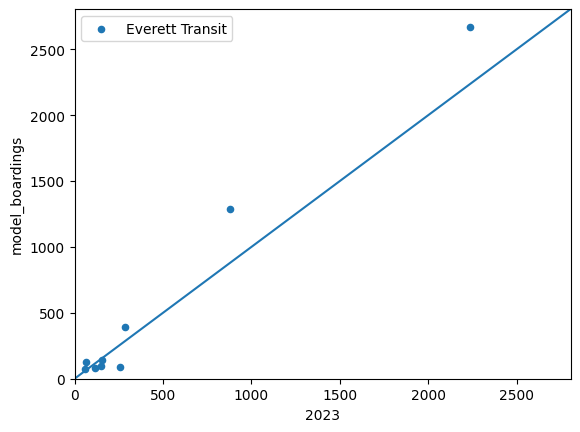

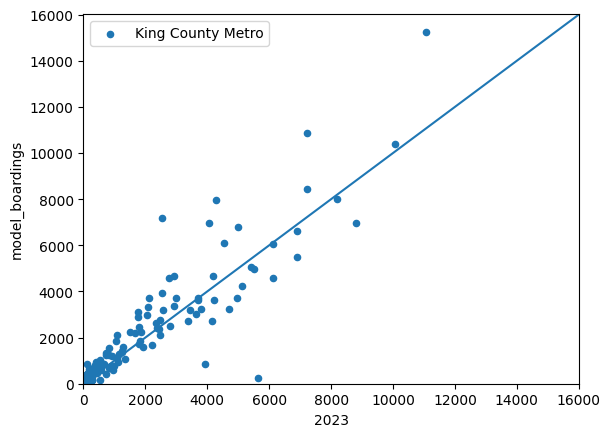

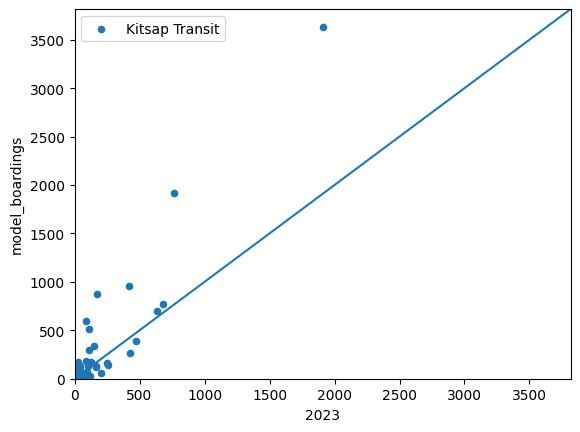

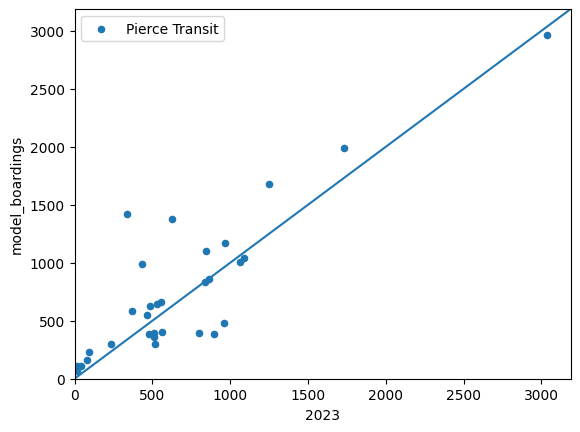

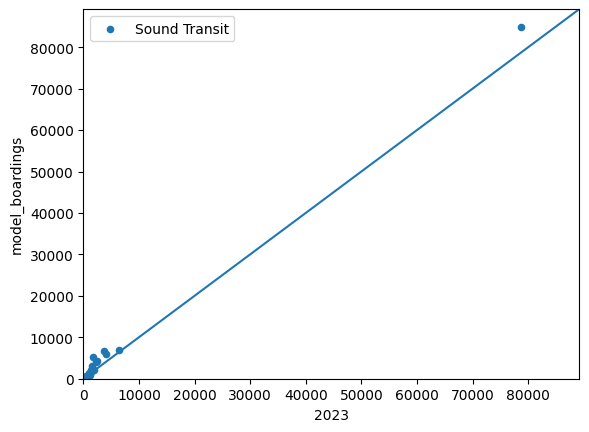

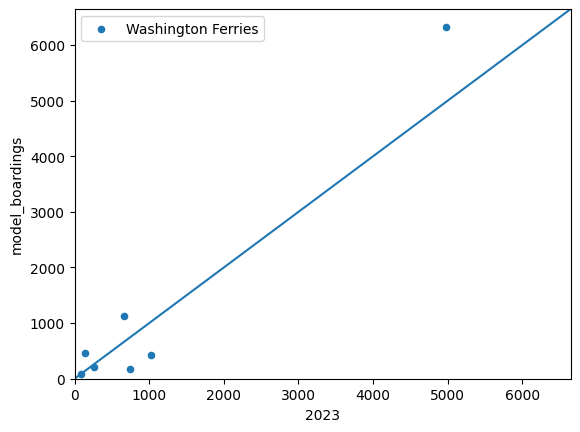

In [30]:

df = pd.read_csv(os.path.join(csv_path,'daily_boardings_by_line.csv'), index_col='agency')
# df = df[-df['agency_id'].isnull()]
df = df[~df['route_id'].isnull()]
for agency in np.unique(df.index):
    _df = df.loc[agency,:]
    if (type(_df) == pd.core.frame.DataFrame) & (len(df) > 0):
        ax = _df.plot(kind='scatter', x='2023', y='model_boardings', label=agency)
        lim = _df[['2023','model_boardings']].max().max()*1.05
        ax.set_ylim(0,lim)
        ax.set_xlim(0,lim)
        x = np.linspace(*ax.get_xlim())
        ax.plot(x, x)
        slope, intercept, r_value, p_value, std_err = stats.linregress(_df['2023'],_df['model_boardings'])
        print('r^2 ' + str(agency) + ': ' + str(r_value))

### boarding by light rail station

In [31]:
df = pd.read_csv(os.path.join(csv_path,'light_rail_boardings.csv'), index_col='station_name')
df['diff'] = df['model_boardings']-df['observed_boardings']
df['percent_diff'] = df['diff']/df['observed_boardings']

df_table = df.copy()
df_table[['percent_diff']] = df_table[['percent_diff']].applymap(format_percent)
df_table

line_1_station_list = ['Northgate Station','Roosevelt Station','University District Station', 
                'Husky Stadium', 'Capitol Hill', 'Westlake', 'Symphony', 'Pioneer Square',
                "Int'l District",  'Stadium', 'SODO', 'Beacon Hill',
               'Mount Baker', 'Columbia City', 'Othello', 'Rainier Beach',
                "Tukwila Int'l Blvd", 'SeaTac/Airport', 'Angle Lake']
t_line_station_list = ['Tacoma Dome Station', 'S 25th St Station', 'Union Station',
       'Convention Center Station', 'Commerce Station']

C:\Users\modeller\AppData\Local\Temp\ipykernel_13212\2244156880.py:6: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [32]:
line_1_df = df_table.loc[line_1_station_list]
df_totals = line_1_df.copy()
df_totals.loc['total']= df_totals.sum(numeric_only=True)
df_totals

,observed_boardings,model_boardings,diff,percent_diff
station_name,,,,
Northgate Station,"9,458","9,202",-256,-2.70%
Roosevelt Station,"4,095","8,302","4,207",102.74%
University District Station,"7,011","8,462","1,451",20.69%
Husky Stadium,"5,440","4,123","-1,317",-24.22%
Capitol Hill,"7,196","7,549",353,4.90%
Westlake,"8,457","9,768","1,311",15.50%
Symphony,"4,137","6,076","1,939",46.88%
Pioneer Square,"4,552","5,260",708,15.55%
Int'l District,"4,278","1,749","-2,529",-59.11%


In [33]:
fig = px.line(line_1_df[['observed_boardings','model_boardings']])
fig.update_layout(height=500, width=900, font=dict(size=11),
                  yaxis_tickformat = '.00f')
fig.show()

In [34]:
t_line_df = df_table.loc[t_line_station_list]
t_line_df.loc['total']= t_line_df.sum(numeric_only=True)
t_line_df

,observed_boardings,model_boardings,diff,percent_diff
station_name,,,,
Tacoma Dome Station,512,276,-236,-46.07%
S 25th St Station,124,524,400,322.97%
Union Station,455,258,-197,-43.19%
Convention Center Station,99,666,567,572.56%
Commerce Station,354,464,110,31.18%
total,"1,544","2,189",645,NaN


In [35]:
df_combined = df.copy()

df_combined['station_group'] = df.index
df_combined.loc[['Westlake'],'station_group'] = 'Westlake/Symphony'
df_combined.loc[['Symphony'],'station_group'] = 'Westlake/Symphony'

df_combined.loc[['Pioneer Square'],'station_group'] = "Pioneer Square/Int'l District"
df_combined.loc[["Int'l District"],'station_group'] = "Pioneer Square/Int'l District"

df_combined.loc[['Stadium'],'station_group'] = 'Stadium/SODO'
df_combined.loc[['SODO'],'station_group'] = 'Stadium/SODO'

df_combined.loc[['Beacon Hill'],'station_group'] = 'Beacon Hill/Mount Baker'
df_combined.loc[['Mount Baker'],'station_group'] = 'Beacon Hill/Mount Baker'

df_combined.loc[['Othello'],'station_group'] = 'Othello/Rainier Beach'
df_combined.loc[['Rainier Beach'],'station_group'] = 'Othello/Rainier Beach'

df_combined.loc[['University District Station'],'station_group'] = 'U District/Husky Stadium'
df_combined.loc[['Husky Stadium'],'station_group'] = 'U District/Husky Stadium'

df_combined.loc[['Northgate Station'],'station_group'] = 'Northgate/Roosevelt'
df_combined.loc[['Roosevelt Station'],'station_group'] = 'Northgate/Roosevelt'

df_combined = df_combined.groupby('station_group').sum()[['observed_boardings','model_boardings']]
df_combined['diff'] = df_combined['model_boardings']-df_combined['observed_boardings']
df_combined['percent_diff'] = df_combined['diff']/df_combined['observed_boardings']
df_combined[['percent_diff']] = df_combined[['percent_diff']].applymap(format_percent)

df_combined = df_combined.loc[['Northgate/Roosevelt','U District/Husky Stadium','Capitol Hill','Westlake/Symphony',"Pioneer Square/Int'l District",
                             'Stadium/SODO','Beacon Hill/Mount Baker','Columbia City','Othello/Rainier Beach',
                             "Tukwila Int'l Blvd",'SeaTac/Airport','Angle Lake']]
df_combined

C:\Users\modeller\AppData\Local\Temp\ipykernel_13212\4163746875.py:28: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed_boardings,model_boardings,diff,percent_diff
station_group,,,,
Northgate/Roosevelt,"13,553","17,504","3,951",29.15%
U District/Husky Stadium,"12,451","12,584",133,1.07%
Capitol Hill,"7,196","7,549",353,4.90%
Westlake/Symphony,"12,594","15,844","3,250",25.81%
Pioneer Square/Int'l District,"8,830","7,009","-1,821",-20.62%
Stadium/SODO,"3,507","3,911",404,11.51%
Beacon Hill/Mount Baker,"3,968","3,059",-909,-22.90%
Columbia City,"1,713","1,665",-48,-2.80%
Othello/Rainier Beach,"3,524","3,974",450,12.76%


In [36]:

fig = px.line(df_combined[['observed_boardings','model_boardings']])
fig.update_layout(height=500, width=900, font=dict(size=11),
                  yaxis_tickformat = '.00f')
fig.show()

In [37]:
df_obs = pd.read_sql(
    "SELECT * FROM light_rail_station_boardings WHERE year IN (2023, 2024)",
    con=conn,
)
df_obs.rename(columns={"boardings": "observed_boardings"}, inplace=True)

# df_obs.groupby(['year','station_name']).sum()
df_obs = pd.pivot_table(df_obs, values='observed_boardings', columns='year', index='station_name', aggfunc=np.sum)
df_obs = df_obs.fillna(0)
df_obs

df = pd.read_csv(os.path.join(csv_path,'light_rail_boardings.csv'), index_col='station_name', usecols=['station_name','model_boardings'])
df = df.merge(df_obs,  left_index=True, right_index=True, how='outer')
df = df[df.index != 'Total']
df = df[~df['model_boardings'].isnull()]
df = df.loc[line_1_station_list]

C:\Users\modeller\AppData\Local\Temp\ipykernel_13212\3655372430.py:8: FutureWarning:

The provided callable <function sum at 0x0000028F59AEF240> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



In [38]:
fig = px.line(df[[2023,2024,'model_boardings']])
fig.update_layout(height=500, width=900, font=dict(size=11),
                  yaxis_tickformat = '.00f')
fig.show()

## light rail stop transfers

In [39]:
df = pd.read_csv(os.path.join(csv_path,'light_rail_transfers.csv'), index_col='station_name')
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df.loc[line_1_station_list]

C:\Users\modeller\AppData\Local\Temp\ipykernel_13212\2177680554.py:2: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,modeled_transfer_rate,observed_transfer_rate,diff,percent_diff
station_name,,,,
Northgate Station,0,-99,99,-100.50%
Roosevelt Station,0,-99,99,-100.42%
University District Station,0,-99,99,-100.19%
Husky Stadium,1,-99,100,-100.82%
Capitol Hill,0,-99,99,-100.06%
Westlake,0,0,-0,-61.30%
Symphony,0,0,0,46.08%
Pioneer Square,0,0,0,142.67%
Int'l District,1,0,0,23.80%
